In [25]:
# The data for this notebook were downloaded from https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L3_MY_008_062
 
# We will use L3 Sea surface height above sea level data from Jason-1 mission in the Gulf of Mexico.
# The data have been already organized in timeseries and stored in Jason-1_l3_timeseries.csv, where for every set of coordinates
# timestaps corresponding to each abservation and sla [m] data have been stored.

# We will perform an Harmonic Analysis on each timeseries to extract the seasonal cycle of the sea level.

# FOR MORE THEORETICAL BACKGROUND SEE LECTURE L11.1_Analysis_Techniques slides 10-21

In [26]:
# Import libraries

import pandas as pd
import numpy as np
import ast
from scipy.optimize import curve_fit, OptimizeWarning
import warnings
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display

In [27]:
# VISUALIZE SPATIAL DISTRIBUTION

# Load the csv
df = pd.read_csv("Jason-1_l3_timeseries.csv")

# Create an interactive scatter plot on a world map
fig = px.scatter_geo(
    df, 
    lat='latitude', 
    lon='longitude',
    title="Jason-1 Satellite Observation Locations",
    projection="natural earth"
)

# Customize the marker size
fig.update_traces(marker=dict(size=3, color="red"))

fig.show()

# Zoom in to see the different acquisitions locations. 
# NOTE: Here we are using L3 data which have already been 
# resampled into nominal tracks. That's why we no longer see 
# the orbital drift discussed in L11.1-repeat-pass_analysis.ipynb

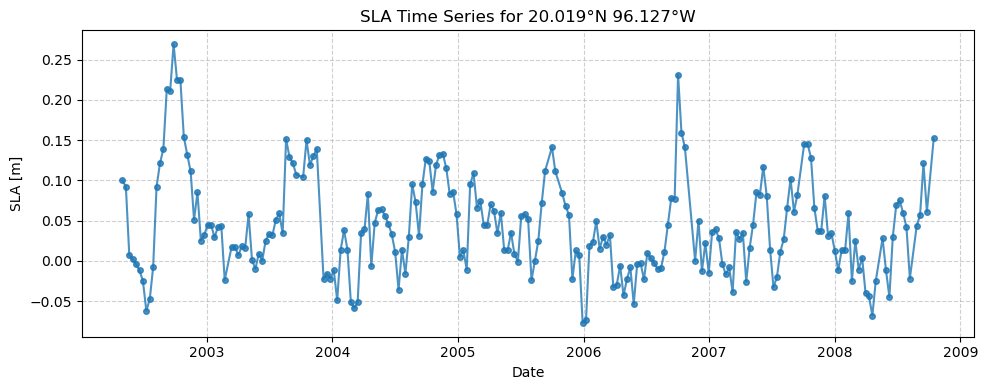

In [28]:
# VISUALIZE A SINGLE LOCATION TIME SERIES

# Choose a location yourself from the map (all decimal digits included)
# or choose a random location based on its index in the csv

# METHOD 1: Select by explicit coordinates
# lat = 
# lon = 

# Look for the row correspondent to the selected location
#row = df[(df['latitude'] == lat) & (df['longitude'] == lon)].iloc[0]

# METHOD 2: Select based on its index in the CSV
row = df.iloc[1000]
    
# Extract data
times = pd.to_datetime(ast.literal_eval(row['time_stamps']))
sla = ast.literal_eval(row['sla_values'])

# Plot time series
plt.figure(figsize=(10, 4))
plt.plot(times, sla, marker='o', linestyle='-', markersize=4, color='#1f77b4', alpha=0.8)
plt.title(f"SLA Time Series for {row['latitude']:.3f}°N {-row['longitude']:.3f}°W")
plt.xlabel("Date")
plt.ylabel("SLA [m]")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


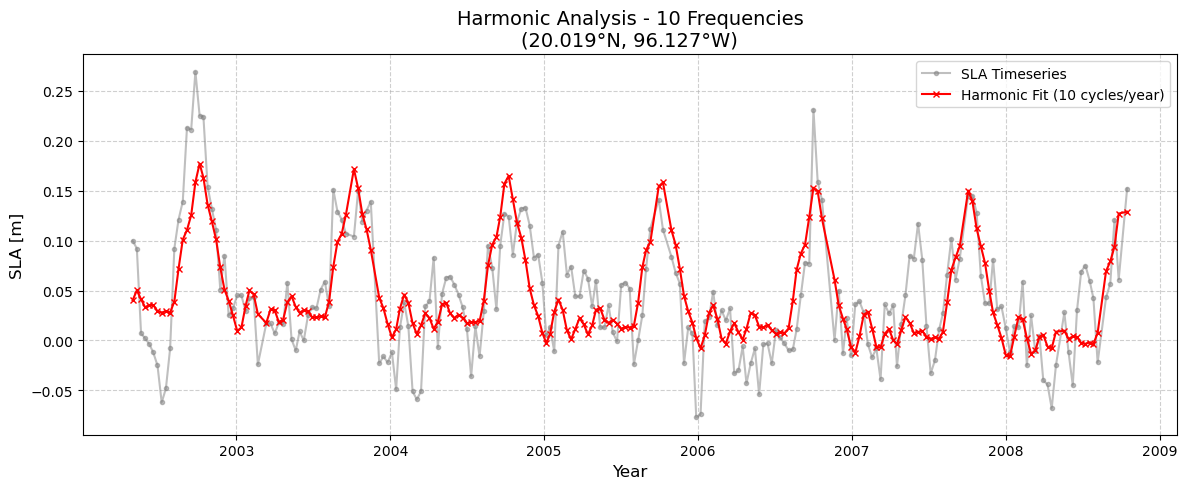

In [29]:
# HARMONIC ANALYSIS

# On the selected time series we now perform the Harmonic Analysis

# We convert the time into decimal years
decimal_years = times.year + (times.dayofyear - 1) / 365.25

# CHOOSE HOW MANY FREQUENCIES! (How many cycles per year to model)
# [ - 1 cycle per year corresponds to the annual cycle
#   - 2 cycles per year corresponds to the semiannual cycle
#   - 3 cycles per year to the a 4 months cycle
#   - ... ]

# NOTE: THE NYQUIST LIMIT
# Jason-1 passes over this exact location once every 10 days. 
# Therefore, the physical cycle with the highest frequency
# we can measure takes 20 days (2 observations * 10 days).

# 365 days / 20 days = ~18 cycles per year.

NUM_FREQUENCIES = 10 #try different ones to visualize the different results

# Define a Dynamic Harmonic Equation using *args
def dynamic_harmonic_model(t, *args):
    # args[0] is the mean offset, args[1] is the linear trend
    result = args[0] + args[1] * t
    omega = 2 * np.pi
    
    # Loop through the remaining arguments in pairs (A and B)
    freq_multiplier = 1
    for i in range(2, len(args), 2):
        A = args[i]
        B = args[i+1]
        
        # Add this specific frequency to the total equation
        result += A * np.cos(freq_multiplier * omega * t) + B * np.sin(freq_multiplier * omega * t)
        
        freq_multiplier += 1
        
    return result

# Set up the initial guesses automatically
# We need 1 for offset, 1 for trend, plus 2 for every frequency we chose
total_parameters = 2 + (2 * NUM_FREQUENCIES)
initial_guess = [0] * total_parameters

# Fit the dynamic curve to the data
params, _ = curve_fit(dynamic_harmonic_model, decimal_years, sla, p0=initial_guess)

# Calculate the fit ONLY at the exact satellite observation times
sla_fit = dynamic_harmonic_model(decimal_years, *params)

# Plot the results
plt.figure(figsize=(12, 5))

# Raw data
plt.plot(decimal_years, sla, marker='.', linestyle='-', color='gray', alpha=0.5, label='SLA Timeseries')

# The fit
plt.plot(decimal_years, sla_fit, marker='x', markersize=4, color='red', linewidth=1.5, 
         label=f'Harmonic Fit ({NUM_FREQUENCIES} cycles/year)')

plt.title(f"Harmonic Analysis - {NUM_FREQUENCIES} Frequencies\n({row['latitude']:.3f}°N, {-row['longitude']:.3f}°W)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("SLA [m]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

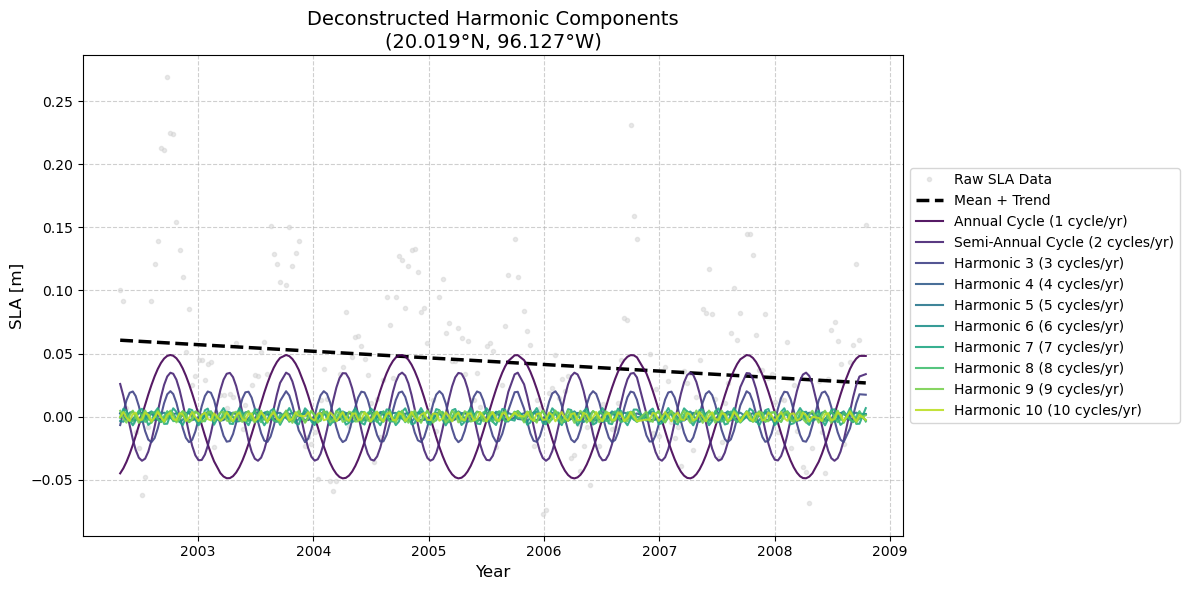

In [30]:
# Decomposition of the fitted curve into periodic functions + a linear trend:

# Extract and plot the Mean + Linear Trend
mean_offset = params[0]
trend = params[1]
trend_line = mean_offset + trend * decimal_years

plt.figure(figsize=(12, 6))

# Plot the raw data
plt.plot(decimal_years, sla, marker='.', linestyle='', color='lightgray', alpha=0.5, label='Raw SLA Data')
# Plot the linear trend
plt.plot(decimal_years, trend_line, color='black', linestyle='--', linewidth=2.5, label='Mean + Trend')

# 3. Loop through and plot each individual frequency wave
omega = 2 * np.pi
freq_multiplier = 1
colors = plt.cm.viridis(np.linspace(0, 0.9, NUM_FREQUENCIES))

for i in range(2, len(params), 2):
    A = params[i]
    B = params[i+1]
    
    # Calculate this single harmonic wave
    component = A * np.cos(freq_multiplier * omega * decimal_years) + B * np.sin(freq_multiplier * omega * decimal_years)
    
    if freq_multiplier == 1:
        label_name = "Annual Cycle (1 cycle/yr)"
    elif freq_multiplier == 2:
        label_name = "Semi-Annual Cycle (2 cycles/yr)"
    else:
        label_name = f"Harmonic {freq_multiplier} ({freq_multiplier} cycles/yr)"
        
    plt.plot(decimal_years, component, color=colors[freq_multiplier-1], 
             linewidth=1.5, alpha=0.9, label=label_name)
    freq_multiplier += 1

plt.title(f"Deconstructed Harmonic Components\n({row['latitude']:.3f}°N, {abs(row['longitude']):.3f}°W)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("SLA [m]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

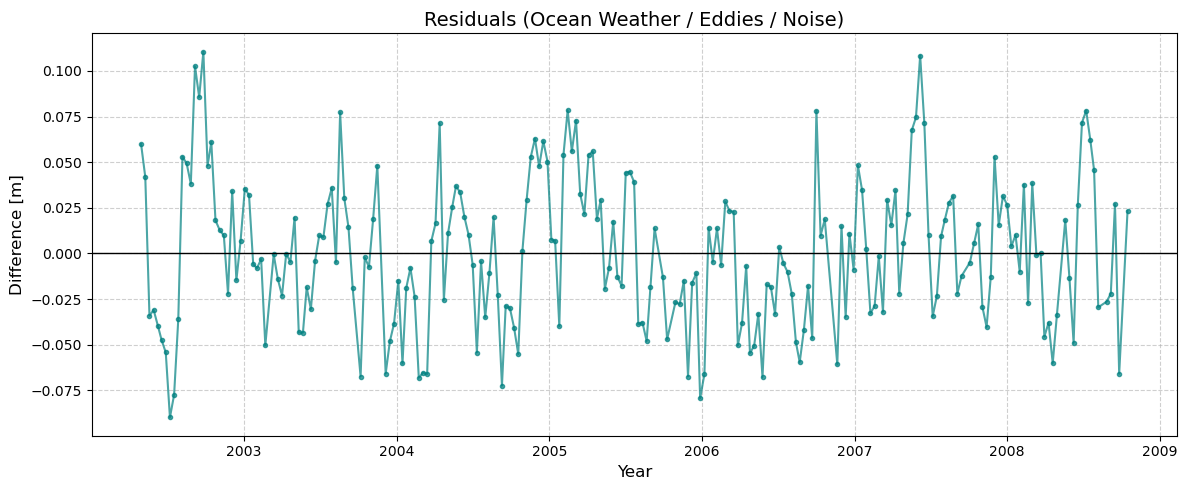

In [31]:
# RESIDUALS 

# Calculate and plot the Residuals
residuals = sla - sla_fit

plt.figure(figsize=(12, 5))

plt.plot(decimal_years, residuals, marker='.', linestyle='-', color='teal', alpha=0.7, label = "residuals")
plt.axhline(0, color='black', linewidth=1)
plt.title("Residuals (Ocean Weather / Eddies / Noise)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Difference [m]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

--- Metrics for Lat: 20.019, Lon: -96.127 ---
Linear Trend: -5.24 mm/year

Annual Cycle Amplitude (1 cycle/yr) = 4.889 cm

Semi-Annual Cycle Amplitude (2 cycles/yr) = 3.493 cm

Amplitude 3 cycles/yr = 2.023 cm

Amplitude 4 cycles/yr = 0.279 cm

Amplitude 5 cycles/yr = 0.322 cm

Amplitude 6 cycles/yr = 0.426 cm

Amplitude 7 cycles/yr = 0.683 cm

Amplitude 8 cycles/yr = 0.440 cm

Amplitude 9 cycles/yr = 0.490 cm

Amplitude 10 cycles/yr = 0.368 cm



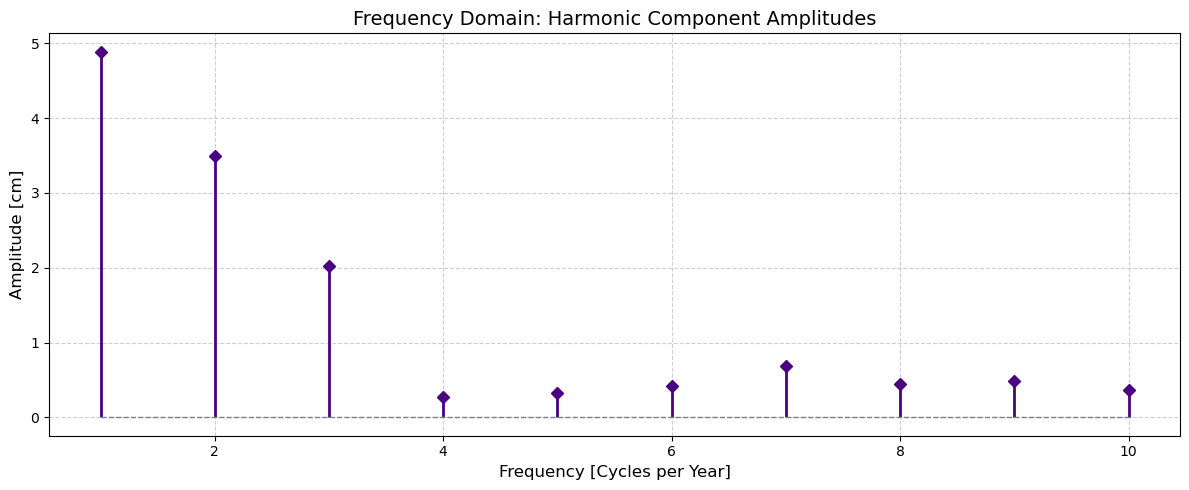

In [32]:
# HARMONIC COMPONENT AMPLITUDES & FREQUENCY SPECTRUM

freq_multiplier = 1
fitted_frequencies = []
fitted_amplitudes_cm = []

# Extract Trend
trend_mm_yr = params[1] * 1000 #conversion in mm/year
print(f"--- Metrics for Lat: {row['latitude']:.3f}, Lon: {row['longitude']:.3f} ---")
print(f"Linear Trend: {trend_mm_yr:.2f} mm/year\n")

for i in range(2, len(params), 2):
    A = params[i]
    B = params[i+1]
    
    # Calculate amplitude and convert from meters to centimeters
    ampl = np.sqrt(A**2 + B**2) * 100 #conversion in cm
    
    if freq_multiplier == 1:
        print(f"Annual Cycle Amplitude (1 cycle/yr) = {ampl:.3f} cm\n") 
    elif freq_multiplier == 2:
        print(f"Semi-Annual Cycle Amplitude (2 cycles/yr) = {ampl:.3f} cm\n")
    else:
        print(f"Amplitude {freq_multiplier} cycles/yr = {ampl:.3f} cm\n")

    fitted_frequencies.append(freq_multiplier)
    fitted_amplitudes_cm.append(ampl)
    freq_multiplier += 1

# Stem plot for the frequency spectrum
plt.figure(figsize=(12, 5))
markerline, stemlines, baseline = plt.stem(
    fitted_frequencies, fitted_amplitudes_cm, 
    linefmt='indigo', markerfmt='D', basefmt="k-"
)
plt.setp(stemlines, linewidth=2)
plt.setp(markerline, markersize=6, color='indigo')
plt.setp(baseline, linewidth=1, color='gray', linestyle='--')

plt.ylabel("Amplitude [cm]", fontsize=12)
plt.xlabel("Frequency [Cycles per Year]", fontsize=12)
plt.title("Frequency Domain: Harmonic Component Amplitudes", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [33]:
# HARMONIC ANALYSIS IN THE WHOLE REGION

# Now that we know how it works let's iterate it for all the locations in Jason-1_l3_timeseries. 
# Here you can again choose the number of frequencies; consider that the bigger the NUM_FREQUENCIES, the more computational time 
# will be required. By iterating the previous steps for different locations, what did you notice in the frequency spectrum? Where
# is most of the signal power concentrated in the frequency domain?

# Here we also compute the ratio of the seasonal variance, which represents the fraction of 
# the total sea level variance explained by the annual and semi-annual harmonic cycles 
# ((ampl_annual^2 / 2) + (ampl_semi_annaul^2 / 2) / sigma_total^2). 
# See lecture slide 18 [Vinogradov et al. 2008]

NUM_FREQUENCIES = 3
total_parameters = 2 + (2 * NUM_FREQUENCIES)
initial_guess = [0] * total_parameters

# Create a single list to hold all of data dictionaries
results_list = []

print(f"Computing harmonic analysis for {len(df)} locations...")

for index, row in df.iterrows():
    try:
        # Extract time and SLA arrays
        times = pd.to_datetime(ast.literal_eval(row['time_stamps']))
        sla = np.array(ast.literal_eval(row['sla_values']))
        decimal_years = times.year + (times.dayofyear - 1) / 365.25
        
        # Fit the mathematical model
        params, _ = curve_fit(dynamic_harmonic_model, decimal_years, sla, p0=initial_guess)

        total_variance = np.var(sla)
        seasonal_variance = ((params[2]**2 + params[3]**2)/2) + ((params[4]**2 + params[5]**2)/2)

        ratio = seasonal_variance / total_variance

        # Create a dictionary with the base parameters
        location_data = {
            'latitude': row['latitude'],
            'longitude': row['longitude'],
            'mean_sla_m': params[0],
            'trend_mm_yr': params[1] * 1000,
            'seasonal_variance_ratio' : ratio
        }
        
        # Dynamically extract all amplitudes based on NUM_FREQUENCIES
        freq_multiplier = 1
        for i in range(2, len(params), 2):
            A = params[i]
            B = params[i+1]
            amplitude_cm = np.sqrt(A**2 + B**2) * 100
            
            # Create dynamic column names ('amp_1_cpy_cm', 'amp_2_cpy_cm'...)
            col_name = f'amp_{freq_multiplier}_cpy_cm'
            location_data[col_name] = amplitude_cm
            
            freq_multiplier += 1
            
        # Append this location's complete dictionary to the list
        results_list.append(location_data)
        
    except Exception as e:
        # Skip locations where the curve_fit mathematically fails
        continue

results_df = pd.DataFrame(results_list)

print("Analysis complete! Preview of the metrics:")
display(results_df.head())

Computing harmonic analysis for 4020 locations...


/tmp/ipykernel_80817/108669990.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(dynamic_harmonic_model, decimal_years, sla, p0=initial_guess)
/tmp/ipykernel_80817/108669990.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(dynamic_harmonic_model, decimal_years, sla, p0=initial_guess)
/tmp/ipykernel_80817/108669990.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(dynamic_harmonic_model, decimal_years, sla, p0=initial_guess)
/tmp/ipykernel_80817/108669990.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(dynamic_harmonic_model, decimal_years, sla, p0=initial_guess)
/tmp/ipykernel_80817/108669990.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(dynamic_harmonic_model, decimal_years, sla, p0=initial_guess)


Analysis complete! Preview of the metrics:


,latitude,longitude,mean_sla_m,trend_mm_yr,seasonal_variance_ratio,amp_1_cpy_cm,amp_2_cpy_cm,amp_3_cpy_cm
0,15.001040,-79.92042,8.383639,-4.167160,0.089380,1.273236,4.606511,6.773556
1,15.004865,-96.93069,3.560619,-1.769018,0.198540,4.390662,3.613724,2.416562
2,15.007193,-99.76611,13.657687,-6.803895,0.159647,2.787266,3.355055,1.181043
3,15.015366,-98.64819,8.033057,-3.994819,0.252411,3.777602,4.502728,2.873124
4,15.016132,-82.76166,4.610561,-2.280286,0.509997,6.023376,1.487119,0.801283


Rendering map for amp_1_cpy_cm...


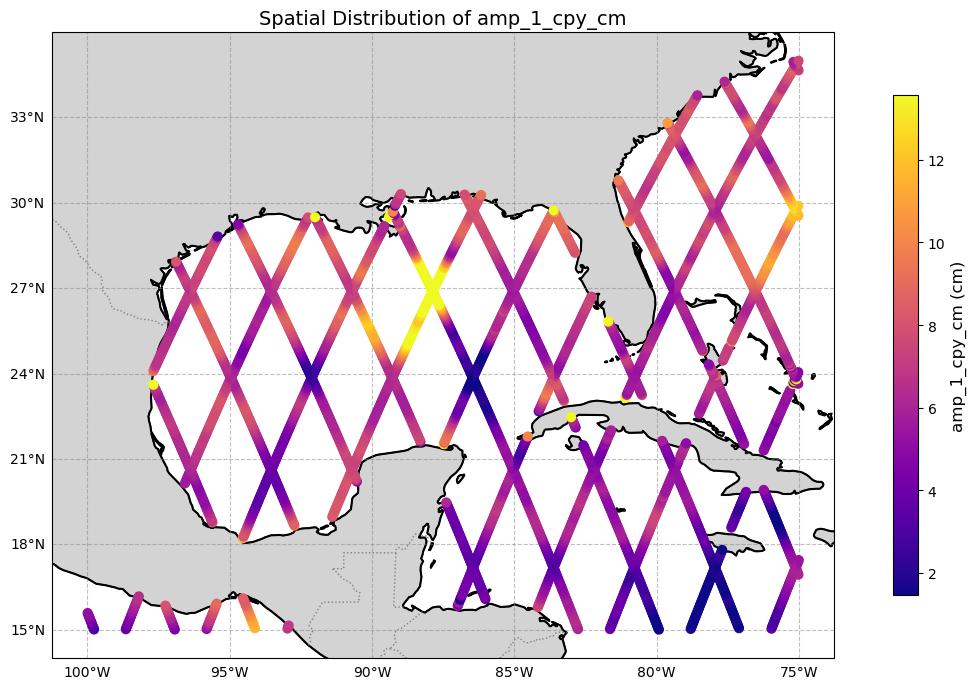

In [34]:
# REGIONAL PLOT 

# We can now see the spatial distribution of the previously extracted metric; choose which one to visualise.
# Options include: 'trend_mm_yr', 'amp_1_cpy_cm', 'amp_2_cpy_cm', 'seasonal_variance_ratio', etc.

TARGET_METRIC = 'amp_1_cpy_cm' 

print(f"Rendering map for {TARGET_METRIC}...")

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add Geographic features (Land, Coastlines, Borders)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=1.5, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray', zorder=2)

# Plot the chosen metric
scatter = ax.scatter(results_df['longitude'], results_df['latitude'], 
                     c=results_df[TARGET_METRIC], cmap='plasma', s=40,
                     vmin=np.percentile(results_df[TARGET_METRIC], 2), vmax=np.percentile(results_df[TARGET_METRIC], 98), 
                     transform=ccrs.PlateCarree(), zorder=3)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.05)

# Dynamically label the colorbar based on the chosen metric
if "trend" in TARGET_METRIC:
    unit = "mm/yr"
elif "ratio" in TARGET_METRIC:
    unit = "fraction"
else:
    unit = "cm"

cbar.set_label(f'{TARGET_METRIC} ({unit})', fontsize=12)

plt.title(f"Spatial Distribution of {TARGET_METRIC}", fontsize=14)
plt.tight_layout()
plt.show()

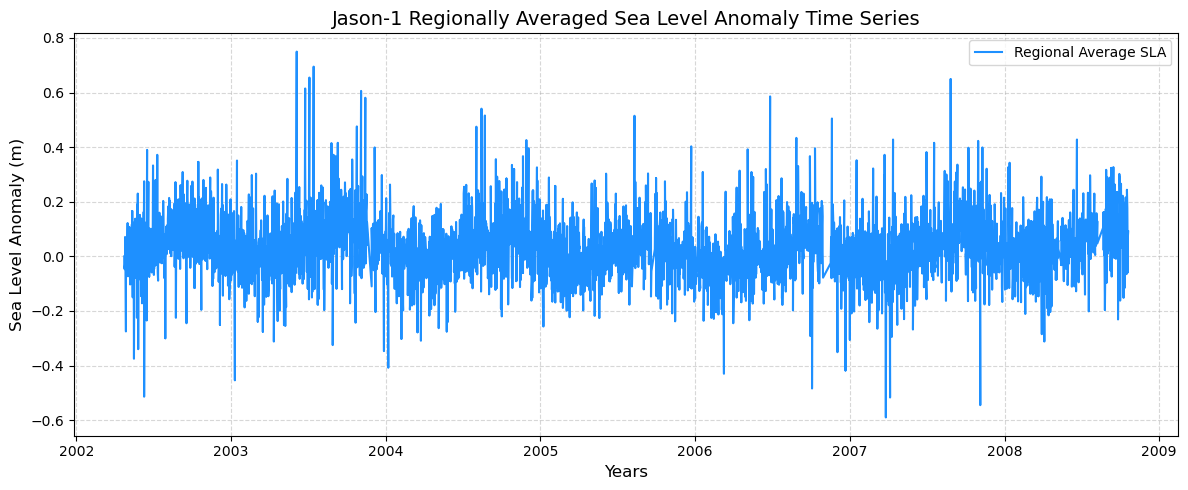

In [35]:
# REGIONAL AVERAGE

# We can also combine all the data in the region in a single time series and apply the same analysis.
# See lecture slide 16

# Combine all time stamps and SLA values into a single master list
all_data = []

for index, row in df.iterrows():
    try:
        times = pd.to_datetime(ast.literal_eval(row['time_stamps']))
        sla = np.array(ast.literal_eval(row['sla_values']))
        
        temp_df = pd.DataFrame({'time': times, 'sla': sla})
        all_data.append(temp_df)
    except Exception:
        continue

# Concatenate all regional data together
master_time_sla_df = pd.concat(all_data, ignore_index=True)

# Group by timestamp and compute the spatial regional mean for each date
regional_avg_df = master_time_sla_df.groupby('time')['sla'].mean().reset_index()
regional_avg_df = regional_avg_df.sort_values('time')

# Prepare variables for analysis
reg_times = pd.to_datetime(regional_avg_df['time'])
reg_sla = regional_avg_df['sla'].values
reg_decimal_years = reg_times.dt.year + (reg_times.dt.dayofyear - 1) / 365.25

# Plot the newly built regional average time series 
# (Since there are too many data points, we downsample and plot every 200th point)
plt.figure(figsize=(12, 5))
plt.plot(reg_decimal_years[::200], reg_sla[::200], label='Regional Average SLA', color='dodgerblue', lw=1.5)
plt.xlabel('Years', fontsize=12)
plt.ylabel('Sea Level Anomaly (m)', fontsize=12)
plt.title('Jason-1 Regionally Averaged Sea Level Anomaly Time Series', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

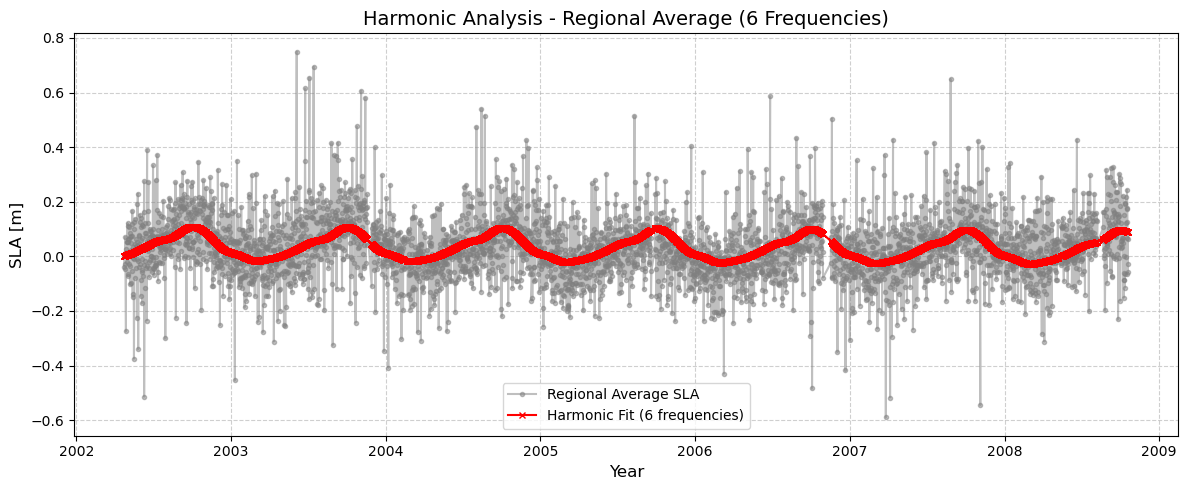

In [36]:
# Let's perform the harmonic analysis on the regional average SLA (reg_sla)

NUM_FREQUENCIES = 6

total_parameters = 2 + (2 * NUM_FREQUENCIES)
initial_guess = [0] * total_parameters

params, _ = curve_fit(dynamic_harmonic_model, reg_decimal_years, reg_sla, p0=initial_guess)

reg_sla_fit = dynamic_harmonic_model(reg_decimal_years, *params)

# Plot the results
plt.figure(figsize=(12, 5))

# Raw data (downsampled for clarity)
plt.plot(reg_decimal_years[::200], reg_sla[::200], marker='.', linestyle='-', color='gray', alpha=0.5, label='Regional Average SLA')

# The fit
plt.plot(reg_decimal_years, reg_sla_fit, marker='x', markersize=4, color='red', linewidth=1.5, 
         label=f'Harmonic Fit ({NUM_FREQUENCIES} frequencies)')

plt.title(f"Harmonic Analysis - Regional Average ({NUM_FREQUENCIES} Frequencies)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("SLA [m]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

--- Physical Metrics for Regional Average SLA ---
Linear Trend (Sea Level Rise): -2.26 mm/year

Annual Cycle Amplitude (1 cycle/yr) = 5.485 cm

Semi-Annual Cycle Amplitude (2 cycles/yr) = 1.008 cm

Amplitude 3 cycles/yr = 0.647 cm

Amplitude 4 cycles/yr = 0.383 cm

Amplitude 5 cycles/yr = 0.066 cm

Amplitude 6 cycles/yr = 0.127 cm



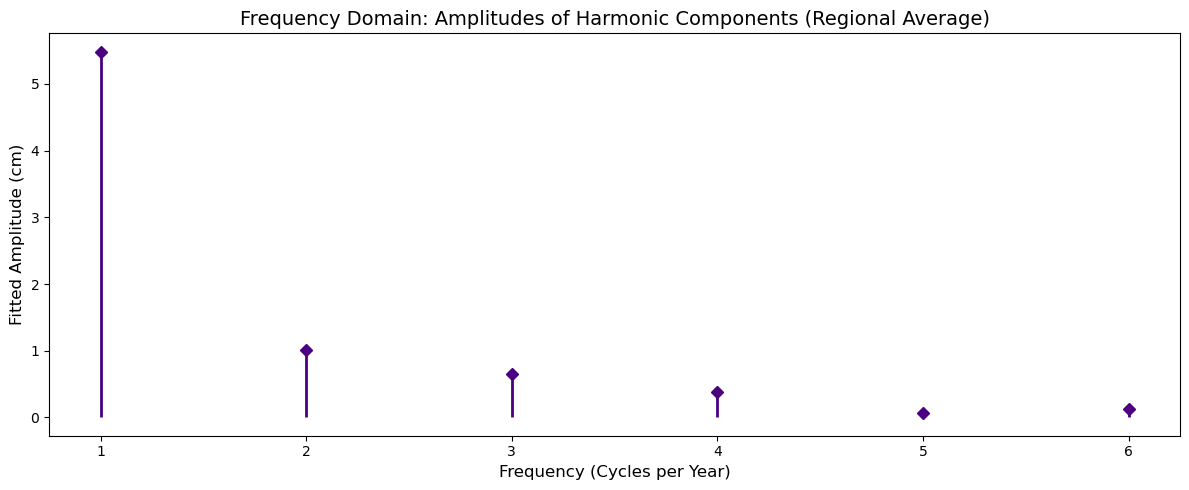

In [37]:
# HARMONIC COMPONENT AMPLITUDES & FREQUENCY SPECTRUM

freq_multiplier = 1
fitted_frequencies = []
fitted_amplitudes_cm = []

# Extract Trend
trend_mm_yr = params[1] * 1000
print(f"--- Physical Metrics for Regional Average SLA ---")
print(f"Linear Trend (Sea Level Rise): {trend_mm_yr:.2f} mm/year\n")

for i in range(2, len(params), 2):
    A = params[i]
    B = params[i+1]
    
    ampl = np.sqrt(A**2 + B**2) * 100  # from m to cm
    
    if freq_multiplier == 1:
        print(f"Annual Cycle Amplitude (1 cycle/yr) = {ampl:.3f} cm\n") 
    elif freq_multiplier == 2:
        print(f"Semi-Annual Cycle Amplitude (2 cycles/yr) = {ampl:.3f} cm\n")
    else:
        print(f"Amplitude {freq_multiplier} cycles/yr = {ampl:.3f} cm\n")

    fitted_frequencies.append(freq_multiplier)
    fitted_amplitudes_cm.append(ampl)
    freq_multiplier += 1

# Stem plot
plt.figure(figsize=(12, 5))
markerline, stemlines, baseline = plt.stem(fitted_frequencies, fitted_amplitudes_cm, 
                                           linefmt='indigo', markerfmt='D', basefmt=" ", 
                                           label='Modeled Harmonic Amplitudes')
plt.setp(stemlines, 'linewidth', 2)
plt.setp(markerline, 'markersize', 6, 'color', 'indigo')

plt.ylabel("Fitted Amplitude (cm)", fontsize=12)
plt.xlabel("Frequency (Cycles per Year)", fontsize=12)
plt.title("Frequency Domain: Amplitudes of Harmonic Components (Regional Average)", fontsize=14)

plt.tight_layout()
plt.show()